## Équation de la chaleur 1D résolution par un PINN

In [40]:
import jax
import jax.numpy as jnp
import functools
import numpy as np
import optax
import matplotlib.pyplot as plt

In [41]:
print(jax.devices())

[CudaDevice(id=0)]


**Domaine et constantes Pyhsique**

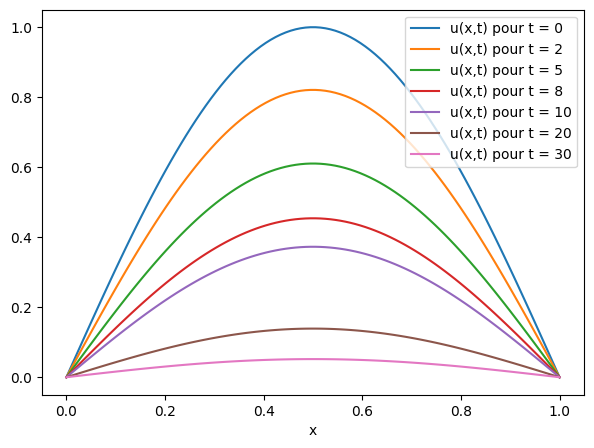

In [42]:
#Longueur de la barre (m)
L = 1
#Temps total de la simulation (s)
T = 30
#Coefficient de diffusion (m^2/s)
kappa = 1e-2
#Valeur propre
omega = jnp.pi/L
#Conditions aux limites de Dirichlet homogènes
#En x=0 u=0 pour tout t
CL0 = 0
#En x=L u=0 pour tout t
CLL = 0
#Condition initial
#u(x,0) = sin(omega*x)
#Exact solution
def u_exact(x,t):
    return jnp.exp(-kappa*omega**2*t)*jnp.sin(omega*x)
#Plot de la solution
time = [0,2,5,8,10,20,30]
x = jnp.linspace(0,L,100)
plt.figure(figsize=(7,5))
for t in time:
    plt.plot(x,u_exact(x,t),label=f"u(x,t) pour t = {t}")
    plt.legend(loc="upper right")
plt.xlabel("x")
plt.show()

**Initialisation des paramètres**

In [43]:
key = jax.random.key(0) #initialisation de la PRNG
#Taille de l'entré
n_input = 2
#Taille de la sortie
n_output = 1
#nombre de couches cachée
n_layers = [n_input,64,64,64,n_output]

def init_layers(key,n_layers):
    layers = []
    for i in range(len(n_layers)-1):
        key, subkey = jax.random.split(key)
        W = jax.random.normal(subkey,(n_layers[i],n_layers[i+1]))/jnp.sqrt(n_layers[i+1])
        key, subkey = jax.random.split(key)
        b = jax.random.normal(subkey,(1,n_layers[i+1]))/jnp.sqrt(n_layers[i+1])
        layers.append({"W" : W,"b" : b})
    return layers, key

key, subkey = jax.random.split(key)
layers, key = init_layers(subkey,n_layers)
#si besoin je peux ajouter kappa comme inconnu par exemple
params = {
    "layers" : layers
}

**Le Forward**

In [44]:
def forward(params,X):
    n = len(params["layers"])
    Z = jax.nn.tanh(X @ params["layers"][0]["W"] + params["layers"][0]["b"])
    for i in range(1,n):
        Z = jax.nn.tanh(Z @ params["layers"][i]["W"] + params["layers"][i]["b"])
    return Z

**La loss function**

In [45]:
#Il faut normaliser les valeurs du réseau
@functools.partial(jax.jit, static_argnames=('N','weights','omega','kappa'))
def loss_fn(params, x, t, omega, kappa, N, weights=(1,1,1)):

    def u(x_val, t_val):
        return forward(params, jnp.array([x_val, t_val])).squeeze()
    
    def pde_residual(x_val, t_val):
        u_t = 2*jax.grad(u, argnums=1)(x_val, t_val)/T
        u_xx = 4*jax.grad(jax.grad(u))(x_val, t_val)/L**2
        return u_t - kappa * u_xx
    
    vmap_u = jax.vmap(u, in_axes=(0,0))
    vmap_pde_residual = jax.vmap(pde_residual, in_axes=(0,0))

    residuals = vmap_pde_residual(x, t)
    pde_loss = jnp.mean(residuals**2)

    zeroscond = -jnp.ones(N)
    x1 = jnp.ones(N)
    bc_loss = jnp.mean((vmap_u(zeroscond, t) - CL0)**2) + jnp.mean((vmap_u(x1, t) - CLL)**2)
    ic_loss = jnp.mean((vmap_u(x,zeroscond)-jnp.sin(omega*(x+1)*L/2))**2)

    total_loss = weights[0]*pde_loss + weights[1]*bc_loss + weights[2]*ic_loss
    
    return total_loss

**Le training**

In [48]:
lr = 3e-4

optimizer = optax.adam(lr)

@functools.partial(jax.jit, static_argnames=('N',))
def train_step(params,opt_state,N,key):
    key, subkey1, subkey2 = jax.random.split(key, 3)
    x = jax.random.uniform(subkey1, (N,), minval=-1, maxval=1)
    t = jax.random.uniform(subkey2, (N,), minval=-1, maxval=1)
    loss, grads = jax.value_and_grad(loss_fn)(params, x, t, omega, kappa, N)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss, key

def train(params, Nmc, num_steps, eval_interval, key):
    opt_state = optimizer.init(params)
    train_loss = []
    rel_err = []
    i = 0
    for step in range(num_steps):
        key, subkey = jax.random.split(key)
        params, opt_state, loss, key = train_step(params, opt_state, Nmc, subkey)
        if step % eval_interval == 0:
            def u(x_val, t_val):
                return forward(params, jnp.array([x_val, t_val])).squeeze()
            key, subkey1, subkey2 = jax.random.split(key, 3)
            x = jax.random.uniform(subkey1, (Nmc,), minval=-1, maxval=1)
            t = jax.random.uniform(subkey2, (Nmc,), minval=-1, maxval=1)
            vmap_u = jax.vmap(u, in_axes=(0,0))
            rel_err.append(jnp.mean((vmap_u(x,t) - u_exact((x+1)*L/2,(t+1)*T/2))**2)/jnp.mean((u_exact((x+1)*L/2,(t+1)*T/2))**2))
            train_loss.append([loss_fn(params, x, t, omega, kappa, Nmc, weights=(1,0,0)),
                          loss_fn(params, x, t, omega, kappa, Nmc, weights=(0,1,0)),
                          loss_fn(params, x, t, omega, kappa, Nmc, weights=(0,0,1))])
            print(f"step {step} | train loss ({train_loss[i][0]:.2e},{train_loss[i][1]:.2e},{train_loss[i][2]:.2e}) | L2 relative error {rel_err[i]*100:.2f} %")
            i+=1
    return params, key, train_loss, rel_err


**La phase d'entrainement**

In [49]:
num_steps = 130000
eval_interval = num_steps//20
Nmc = 5000

key, subkey = jax.random.split(key)
best_params, key, train_loss, test_loss = train(params, Nmc, num_steps, eval_interval, subkey)

step 0 | train loss (2.05e-06,1.81e+00,2.17e-01) | L2 relative error 733.51 %
step 6500 | train loss (5.87e-04,1.78e-04,4.42e-04) | L2 relative error 10.70 %
step 13000 | train loss (2.62e-04,1.67e-04,2.11e-04) | L2 relative error 3.57 %
step 19500 | train loss (1.75e-04,9.38e-06,1.05e-04) | L2 relative error 1.46 %
step 26000 | train loss (1.14e-04,6.84e-05,7.91e-05) | L2 relative error 0.92 %
step 32500 | train loss (9.59e-05,2.42e-05,5.73e-05) | L2 relative error 0.41 %
step 39000 | train loss (7.74e-05,2.94e-06,4.09e-05) | L2 relative error 0.30 %
step 45500 | train loss (6.55e-05,3.69e-06,3.49e-05) | L2 relative error 0.19 %
step 52000 | train loss (5.33e-05,2.61e-05,3.17e-05) | L2 relative error 0.18 %
step 58500 | train loss (4.74e-05,3.05e-05,2.99e-05) | L2 relative error 0.14 %
step 65000 | train loss (4.03e-05,5.30e-06,2.24e-05) | L2 relative error 0.09 %
step 71500 | train loss (3.96e-05,1.47e-05,2.38e-05) | L2 relative error 0.06 %
step 78000 | train loss (3.76e-05,1.46e-03

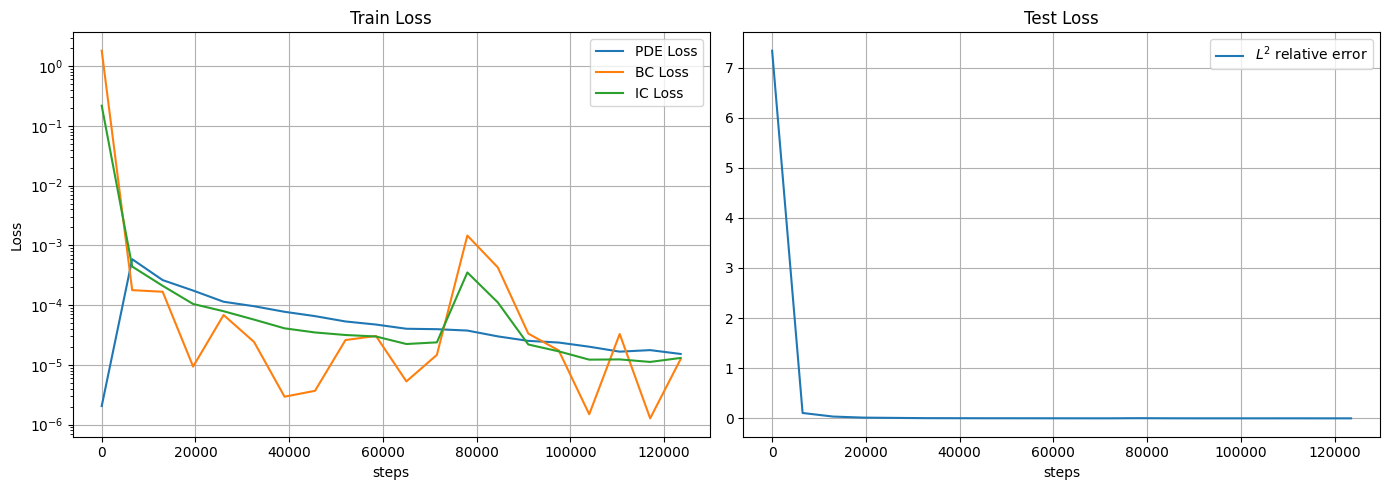

In [50]:
#Print des métriques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.semilogy(eval_interval*np.arange(num_steps//eval_interval), np.array(train_loss)[:,0], label="PDE Loss")
ax1.semilogy(eval_interval*np.arange(num_steps//eval_interval), np.array(train_loss)[:,1], label="BC Loss")
ax1.semilogy(eval_interval*np.arange(num_steps//eval_interval), np.array(train_loss)[:,2], label="IC Loss")

ax2.plot(eval_interval*np.arange(num_steps//eval_interval), test_loss, label="$L^2$ relative error")

ax1.set_title("Train Loss")
ax1.set_xlabel("steps")
ax1.set_ylabel("Loss")
ax1.legend(loc="upper right")
ax1.grid(True)

ax2.set_title("Test Loss")
ax2.set_xlabel("steps")
ax2.legend(loc="upper right")
ax2.grid(True)

plt.tight_layout()
plt.show()

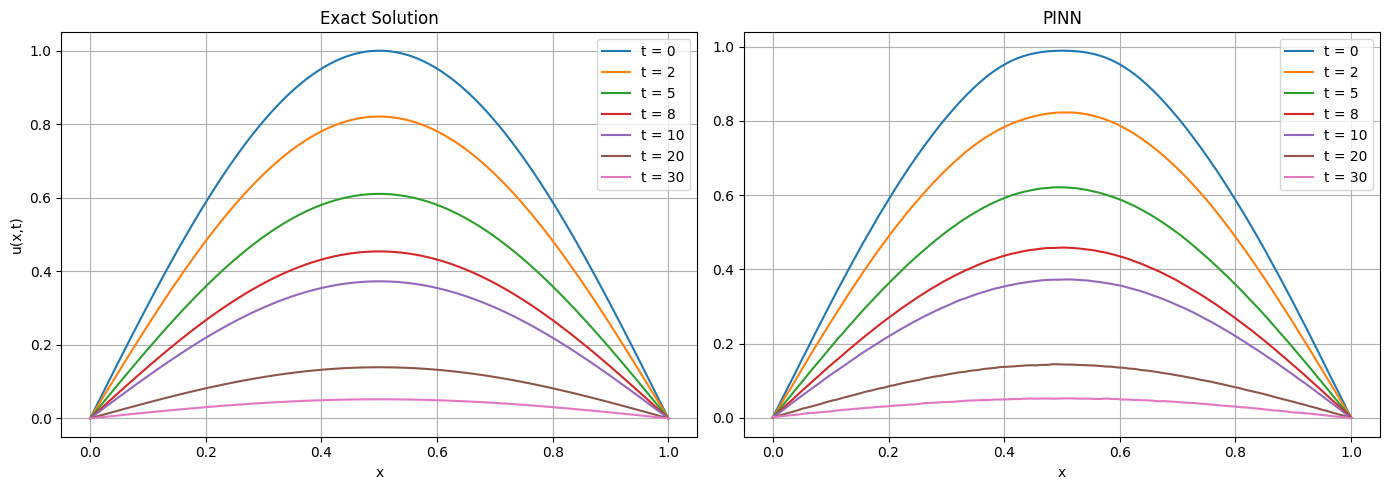

In [51]:
#Plot de la solution et de l'approximation du PINN
def u_pinn(x, t):
    return forward(best_params, jnp.array([x, t])).squeeze()

time = [0,2,5,8,10,20,30]
x = jnp.linspace(0,L,100)

vmap_u_pinn = jax.vmap(u_pinn, in_axes=(0, None))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for t in time:
    ax1.plot(x, u_exact(x,t), label=f"t = {t}")
    ax2.plot(x, vmap_u_pinn(2*x/L-1,2*t/T-1), label=f"t = {t}")

ax1.set_title("Exact Solution")
ax1.set_xlabel("x")
ax1.set_ylabel("u(x,t)")
ax1.legend(loc="upper right")
ax1.grid(True)

ax2.set_title("PINN")
ax2.set_xlabel("x")
ax2.legend(loc="upper right")
ax2.grid(True)

plt.tight_layout()
plt.savefig('Heat_eq_1D_test_PINN.pdf')
plt.show()